In [2]:
from ipow.generators import (
    Xoshiro256StarStar,
    SplitMix64,
    WELL512a,
    BlumBlumShub,
    JSF32,
    ChaCha20RNG,
)
from ipow.tests import ValidationConfig, validate_generator, run_visual_tests

In [3]:
import json

cfg = ValidationConfig(n_numbers=5000, n_bits=10000)

## Xoshiro256StarStar

Xoshiro256** (od operacji XOR, shift, rotate) to nowoczesny i  wydajny generator liczb pseudolosowych o 256-bitowym stanie wewnętrznym (zainicjalizowanym przez algorytm SplitMix64). Przyrostek ** oznacza metodę "mieszania" wyniku za pomocą mnożenia i rotacji, co zapewnia większoą jakość losowanych liczb i pomaga ukryć liniowość wewnętrznego stanu. Stosowany jest gdy wymagana jest duża wydajność generowania kolejnych liczb np. symulacja monte carlo lub machine learning. Nie jest kryptograficznie bezpieczny.

Każde losowanie opiera się na trzech szybkich krokach:

1. Odczyt: Algorytm pobiera obecny stan podzielony na cztery 64-bitowe zmienne (s0, s1, s2, s3).

2. Wyliczenie wyniku (Scrambler **): Druga zmienna (s1) jest mnożona, poddawana rotacji i ponownie mnożona. Ten "zmieszany" wynik jest zwracany użytkownikowi.

3. Aktualizacja stanu: Wszystkie cztery zmienne są modyfikowane poprzez kaskadę przesunięć i operacji XOR, tworząc nowy stan gotowy na kolejne losowanie.

{
  "generator": "Xoshiro256**",
  "summary_numbers": {
    "count": 5000.0,
    "mean": 9.449402164968604e+18,
    "variance": 2.8217383576797404e+37,
    "std": 5.312003725224353e+18,
    "min": 376529549420511.0,
    "max": 1.844390451197064e+19
  },
  "summary_floats": {
    "count": 5000.0,
    "mean": 0.5074813349508542,
    "variance": 0.08349605514094734,
    "std": 0.28895683958153223,
    "min": 4.758641946489561e-06,
    "max": 0.9998264384743553
  },
  "bit_balance": {
    "count": 10000,
    "zeros": 4992,
    "ones": 5008,
    "p_zero": 0.4992,
    "p_one": 0.5008
  },
  "serial_pairs": {
    "00": 2490,
    "01": 2501,
    "10": 2502,
    "11": 2506
  },
  "tests": {
    "monobit": {
      "statistic": 0.16,
      "p_value": 0.8728810742171343,
      "pass": true
    },
    "runs": {
      "statistic": 5004.0,
      "p_value": 0.936033488790942,
      "pass": true
    },
    "chi_square_uint64_mod_256": {
      "statistic": 267.04640000000006,
      "p_value": 0.28956378

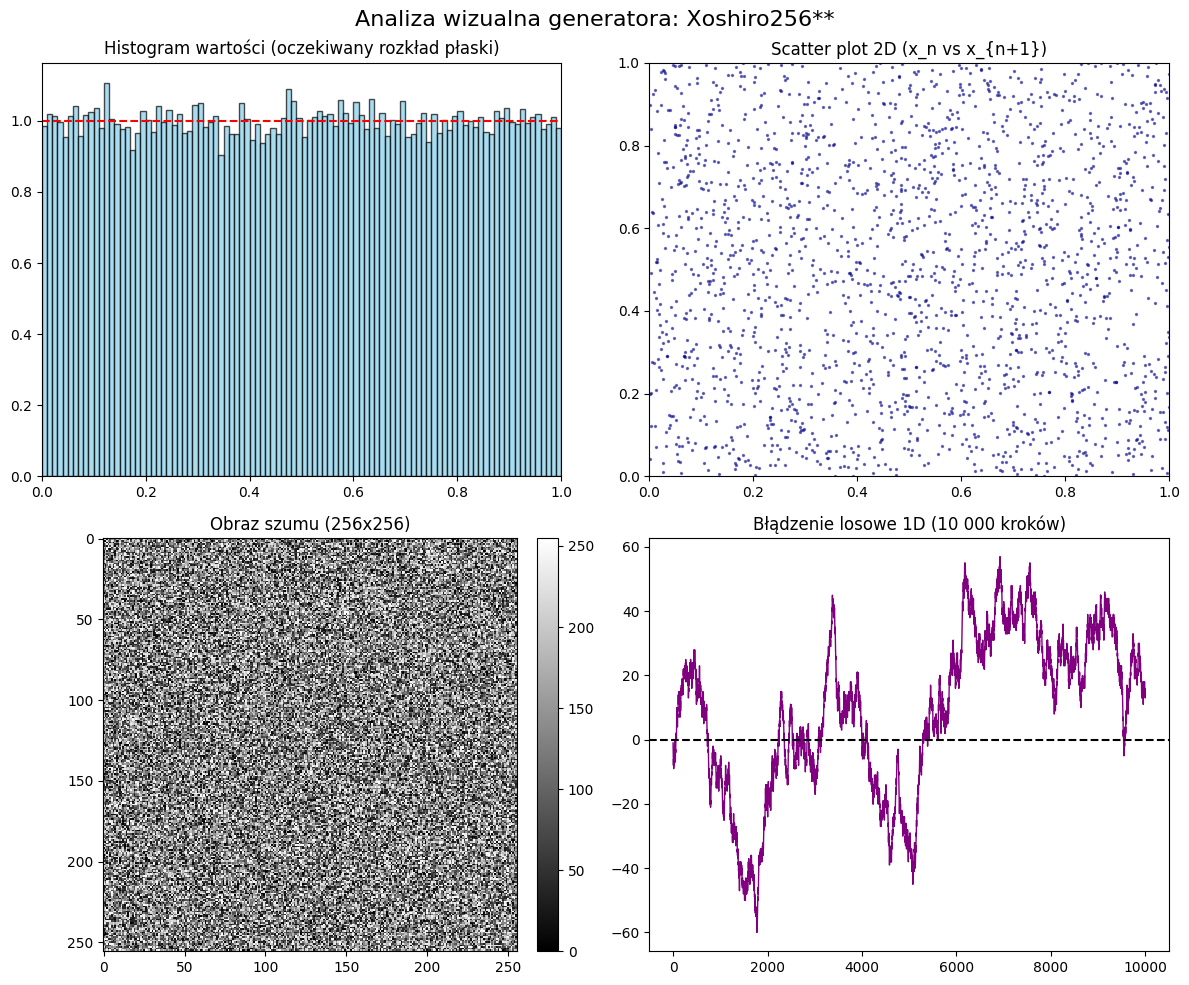

In [4]:
generator = Xoshiro256StarStar(seed=12345)
results = validate_generator(generator, cfg)
print(json.dumps(results, indent=2))
run_visual_tests(generator)

## SplitMax64

SplitMix64 to bardzo prosty, szybki i lekki generator liczb pseudolosowych oparty na zaledwie 64-bitowym stanie wewnętrznym. Wykorzystuje stałą sekwencję Weyla do aktualizacji stanu oraz kaskadowe mieszanie bitów  do wyliczenia ostatecznego wyniku. W przeciwieństwie do wielu generatorów (jak np. Xoshiro), doskonale radzi sobie z ziarnem (seed) składającym się z samych zer. Stan generatora można odtworzyć dysponując już zaledwie jednym wygenerowanym wynikiem, więc nie jest kryptograficznie bezpieczny. 

Służy głownie go inicjalizowanie innych generatorów oraz prostych zastosowań, gdzie nie szkodzi prostota i którki cykl generowania.

Losowanie polega na:

1. Aktualizacja stanu (Sekwencja Weyla): Do aktualnego stanu wewnętrznego dodawana jest bardzo duża stała matematyczna (0x9E3779B97F4A7C15). To zwykłe dodawanie gwarantuje, że generator ma dokładnie zdefiniowany cykl i przejdzie przez wszystkie możliwe wartości 64-bitowe.

2. Mieszanie (Avalanche effect): Nowy stan jest kopiowany do zmiennej pomocniczej z, która następnie poddawana jest brutalnemu "mieszaniu". Przechodzi przez serię naprzemiennych operacji XOR z przesunięciem bitowym i mnożenia przez kolejne wielkie stałe.
To mocno zmodyfikowane z trafia do użytkownika, podczas gdy właściwy stan generatora pozostaje po prostu wynikiem dodawania z kroku pierwszego.

{
  "generator": "SplitMix64",
  "summary_numbers": {
    "count": 5000.0,
    "mean": 9.341454670339279e+18,
    "variance": 2.9083434339180888e+37,
    "std": 5.392905927158463e+18,
    "min": 9339123016694376.0,
    "max": 1.8446672072755059e+19
  },
  "summary_floats": {
    "count": 5000.0,
    "mean": 0.5001344305963423,
    "variance": 0.08447609980530517,
    "std": 0.29064772458305116,
    "min": 4.143970018066767e-05,
    "max": 0.9999067644869947
  },
  "bit_balance": {
    "count": 10000,
    "zeros": 4998,
    "ones": 5002,
    "p_zero": 0.4998,
    "p_one": 0.5002
  },
  "serial_pairs": {
    "00": 2486,
    "01": 2512,
    "10": 2511,
    "11": 2490
  },
  "tests": {
    "monobit": {
      "statistic": 0.04,
      "p_value": 0.9680931262943385,
      "pass": true
    },
    "runs": {
      "statistic": 5024.0,
      "p_value": 0.6312159614240189,
      "pass": true
    },
    "chi_square_uint64_mod_256": {
      "statistic": 260.5952,
      "p_value": 0.39148801821888657

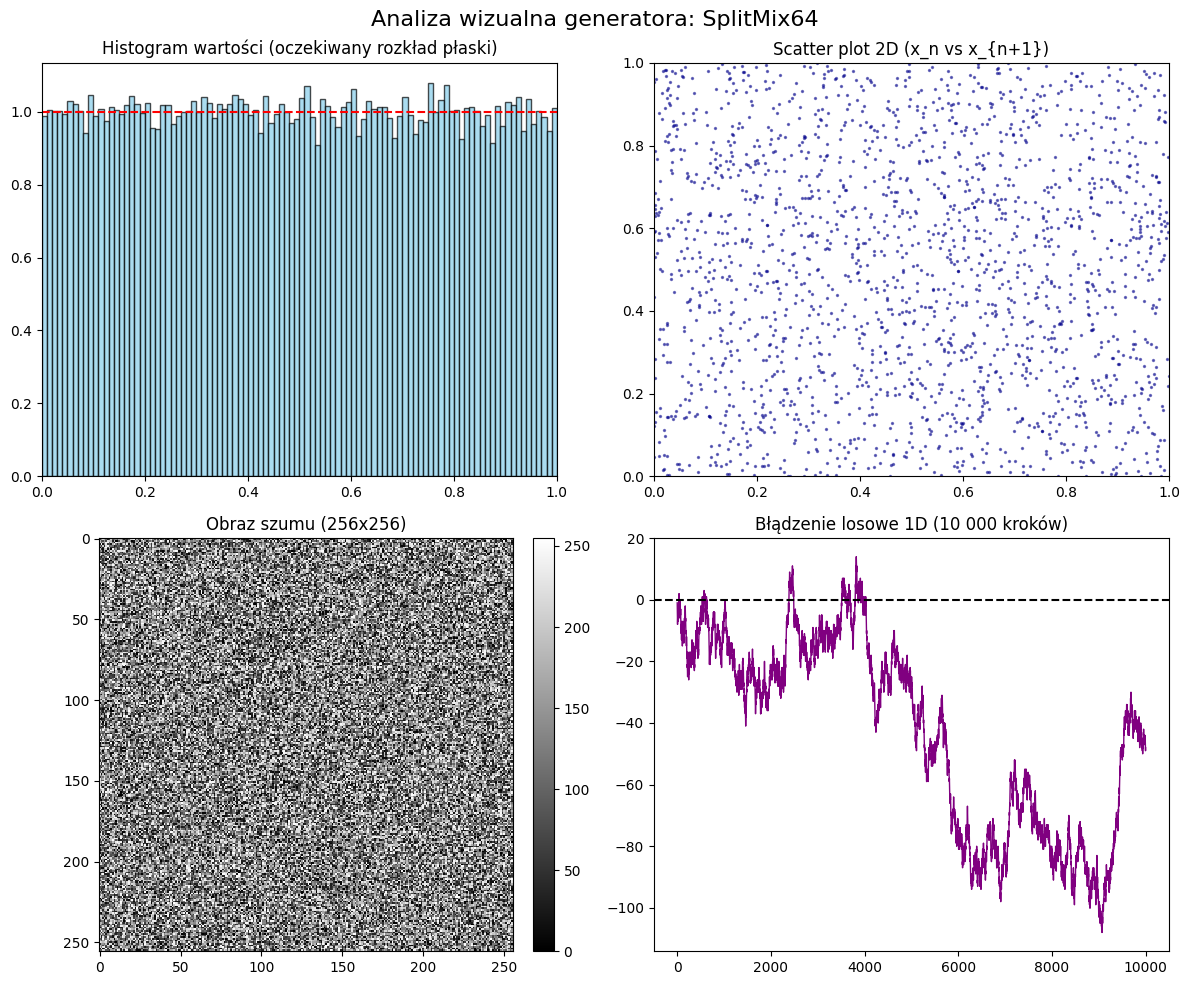

In [5]:
generator = SplitMix64(seed=12345)
results = validate_generator(generator, cfg)
print(json.dumps(results, indent=2))
run_visual_tests(generator)

## WELL512a

WELL512a (od Well Equidistributed Long-period Linear) to zaawansowany generator liczb pseudolosowych zaprojektowany jako bezpośredni, udoskonalony następca słynnego Mersenne Twistera. Posiada 512-bitowy stan wewnętrzny zorganizowany jako tablica szesnastu 32-bitowych liczb, wspierana przez cykliczny indeks. Jego najewiększa przewaga nad poprzednikiem to odpornośc na zeroload. Jak większość szybkich generatorów ogólnego przeznaczenia, można łatwo przewidzieć jego kolejne wyniki, znając fragment sekwencji wyjściowej (brak bezpieczeństwa kryptograficznego). 

Jest wykorzystywany w symulacjach naukowych, grach oraz analizie wielowymiarowych danych.

Proces generwania liczb:

1. Odczyt z bufora: Algorytm nie bierze całego stanu naraz. Odczytuje wartości z tablicy dla bieżącego indeksu oraz dla indeksów przesuniętych o konkretne wartości.

2. Kaskada transformacji: Odczytane liczby są xorowane ze sobą, a także poddawane  przesunięciom bitowym (w lewo i w prawo) oraz maskowaniu za pomocą określonych stałych matematycznych (mask).

3. Zapis i rotacja indeksu: Wyliczone, wymieszane wartości są zapisywane z powrotem do tablicy stanu, a sam indeks jest zmniejszany o 1 (operacja (i + 15) & 15 cofa go w pętli 16-elementowej). Ostatnia zliczona wartość jest zwracana użytkownikowi jako wylosowana liczba.

{
  "generator": "WELL512a",
  "summary_numbers": {
    "count": 5000.0,
    "mean": 9.377420547100733e+18,
    "variance": 2.848749868126607e+37,
    "std": 5.337368141815409e+18,
    "min": 7792621342596206.0,
    "max": 1.8445139890441183e+19
  },
  "summary_floats": {
    "count": 5000.0,
    "mean": 0.49368301867992714,
    "variance": 0.08357515814217951,
    "std": 0.28909368402332747,
    "min": 2.8691645592937576e-05,
    "max": 0.9992098294604698
  },
  "bit_balance": {
    "count": 10000,
    "zeros": 4963,
    "ones": 5037,
    "p_zero": 0.4963,
    "p_one": 0.5037
  },
  "serial_pairs": {
    "00": 2465,
    "01": 2497,
    "10": 2498,
    "11": 2539
  },
  "tests": {
    "monobit": {
      "statistic": 0.74,
      "p_value": 0.4592999943295813,
      "pass": true
    },
    "runs": {
      "statistic": 4996.0,
      "p_value": 0.9405901977615987,
      "pass": true
    },
    "chi_square_uint64_mod_256": {
      "statistic": 274.21439999999996,
      "p_value": 0.19497842

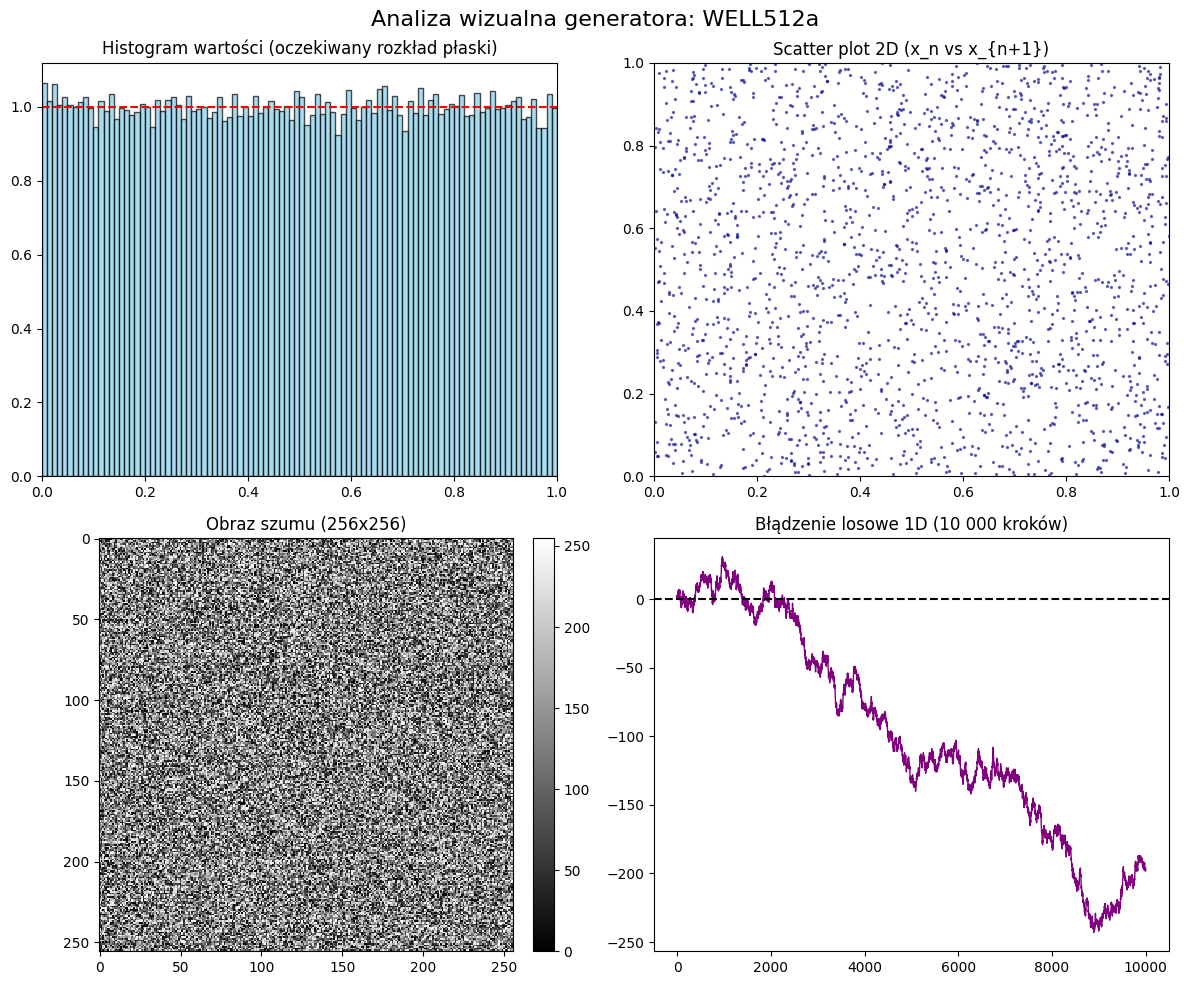

In [6]:
generator = WELL512a(seed=12345)
results = validate_generator(generator, cfg)
print(json.dumps(results, indent=2))
run_visual_tests(generator)

## BlumBlumShub

Blum Blum Shub (BBS) to kryptograficznie bezpieczny generator liczb pseudolosowych.  W przeciwieństwie do wcześniej prostszych generatorów opartych na prostych operacjach bitowych, BBS opiera się na złożonych operacjach z dziedziny teorii liczb i twardych problemach matematycznych. Jego nieprzewidywalność udowodniono matematycznie – opiera się na problemie trudności faktoryzacji dużych liczb całkowitych. Ze względu na to, że przy każdym kroku wykorzystuje ciężkie operacje arytmetyczne (potęgowanie dużych liczb z resztą z dzielenia), jest znacznie wolniejszy od innych. Wymaga tzw. liczb pierwszych Bluma gdzie obie liczby dają resztę 3 przy dzieleniu przez 4 - p i q, których poznanie pozwala na przewidzenie kolejnych liczb. Generowane są pojedyncze bity liczb, a nie cała wartość. 

Używany w kryptografii i generowaniu tokenów, choć obecnie zastępowany prze szybsze generatory np. AES.

Zamiast mieszać bity, algorytm opiera się na rekurencyjnym wzorze matematycznym: 
$x_{i+1} = x_i^2 \pmod n$.

Proces generowania: 

1. Inicjalizacja : Na podstawie dwóch wielkich liczb pierwszych $p$ i $q$ wyliczany jest moduł $n = p \times q$. Następnie ziarno początkowe podnosi się do kwadratu modulo $n$, tworząc stan startowy.

2. Generowanie pojedynczego bitu: Obecny stan podnoszony jest do kwadratu modulo $n$ (pow(self.state, 2, self.n)). Z powstałej w ten sposób wielkiej liczby pobierany jest tylko jeden, najmniej znaczący bit (parzystość) za pomocą operacji & 1.

3. Składanie większych liczb: Aby wygenerować pełną, 64-bitową , algorytm musi  wykonać powyższą, kosztowną operację potęgowania aż 64 razy, wstawiając w każdej pętli jeden bit na odpowiednią pozycję za pomocą przesunięcia bitowego (<<).

{
  "generator": "BlumBlumShub",
  "summary_numbers": {
    "count": 5000.0,
    "mean": 9.157162474774574e+18,
    "variance": 2.84724824016242e+37,
    "std": 5.335961244389261e+18,
    "min": 3965393384869732.0,
    "max": 1.844177655733448e+19
  },
  "summary_floats": {
    "count": 5000.0,
    "mean": 0.5002945125954221,
    "variance": 0.08536419550911432,
    "std": 0.29217151727900226,
    "min": 9.867550439657258e-05,
    "max": 0.9999388218410757
  },
  "bit_balance": {
    "count": 10000,
    "zeros": 4978,
    "ones": 5022,
    "p_zero": 0.4978,
    "p_one": 0.5022
  },
  "serial_pairs": {
    "00": 2477,
    "01": 2500,
    "10": 2501,
    "11": 2521
  },
  "tests": {
    "monobit": {
      "statistic": 0.44,
      "p_value": 0.6599371073211873,
      "pass": true
    },
    "runs": {
      "statistic": 5002.0,
      "p_value": 0.9665490705493325,
      "pass": true
    },
    "chi_square_uint64_mod_256": {
      "statistic": 257.6256,
      "p_value": 0.44221028685960106,

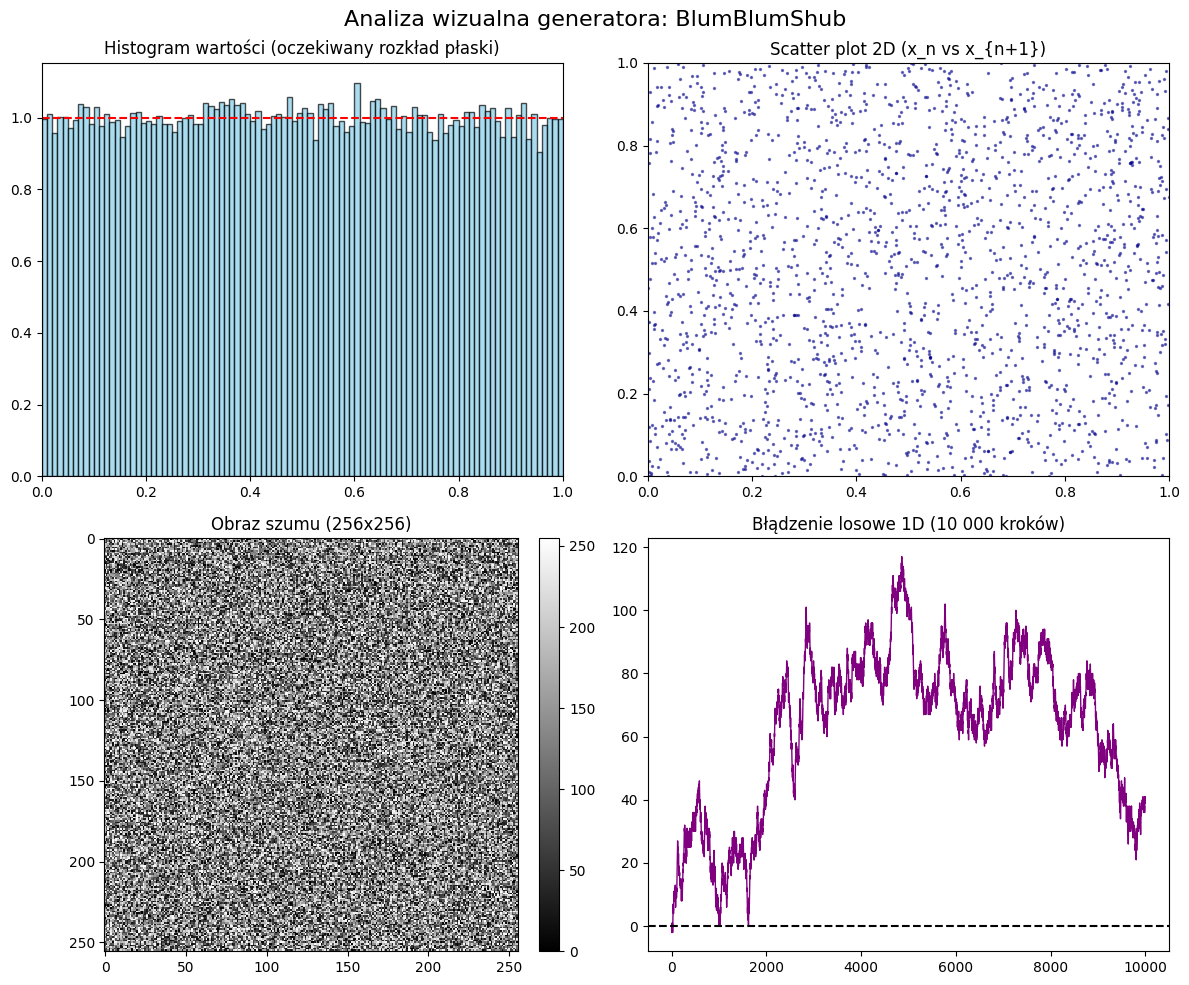

In [7]:
generator = BlumBlumShub(seed=12345)
results = validate_generator(generator, cfg)
print(json.dumps(results, indent=2))
run_visual_tests(generator)

## JSF32

JSF32 (od Jenkins' Small Fast) to bardzo wydajny generator liczb pseudolosowych. Został stworzony z myślą o maksymalnej szybkości i minimalnym zużyciu pamięci, opierając się na architekturze 32-bitowej i operacjach typu "chaotic PRNG" (chaotyczne mieszanie stanu).
Cały stan wewnętrzny to zaledwie 128 bitów (cztery 32-bitowe zmienne: a, b, c, d). Algorytm używa najprostszych instrukcji procesora.
Podczas inicjalizacji (warmup) generator celowo wykonuje 20 pustych przebiegów, odrzucając ich wyniki. Pozwala to na wymieszanie ziarna początkowego i zapobiega niskiej jakości pierwszych wylosowanych liczb. 

Przeznaczony jest głownie do symulacji statystycznych, nie jest bezpieczny kryptograficznie. Wykorzystywany w IoT, grach, renderowaniu oraz prostych symulacjach. 

Pracuje natywnie na liczbach 32-bitowych (aby uzyskać 64-bitowy wynik, metoda _next_uint64 po prostu losuje  dwa razy i skleja wyniki).

Proces generowania:

1. Zmienna tymczasowa: Obliczana jest pomocnicza wartość e poprzez odjęcie zrotowanej wartości b od a. Wprowadza to nieliniowość matematyczną. 

2. Kaskadowa aktualizacja: Stan jest aktualizowany lawinowo. Nowe a powstaje z b oraz zrotowanego c (używając XOR). Nowe b to suma c i d. Nowe c to suma d i e.

3. Wynik: Na samym końcu nowe d to suma e oraz a. Ta właśnie wartość d ląduje w zmiennych stanu i jest jednocześnie natychmiast zwracana użytkownikowi jako wylosowana liczba.


{
  "generator": "JSF32",
  "summary_numbers": {
    "count": 5000.0,
    "mean": 9.207393697356573e+18,
    "variance": 2.865662384544766e+37,
    "std": 5.35318819447324e+18,
    "min": 779602526460920.0,
    "max": 1.8441881524913365e+19
  },
  "summary_floats": {
    "count": 5000.0,
    "mean": 0.5009113701179511,
    "variance": 0.08250324440223566,
    "std": 0.28723378005073785,
    "min": 0.00011237243947603837,
    "max": 0.9997851895592771
  },
  "bit_balance": {
    "count": 10000,
    "zeros": 5086,
    "ones": 4914,
    "p_zero": 0.5086,
    "p_one": 0.4914
  },
  "serial_pairs": {
    "00": 2555,
    "01": 2531,
    "10": 2530,
    "11": 2383
  },
  "tests": {
    "monobit": {
      "statistic": 1.72,
      "p_value": 0.08543244158265789,
      "pass": true
    },
    "runs": {
      "statistic": 5062.0,
      "p_value": 0.20409898394836232,
      "pass": true
    },
    "chi_square_uint64_mod_256": {
      "statistic": 233.0496,
      "p_value": 0.8343791893037975,
    

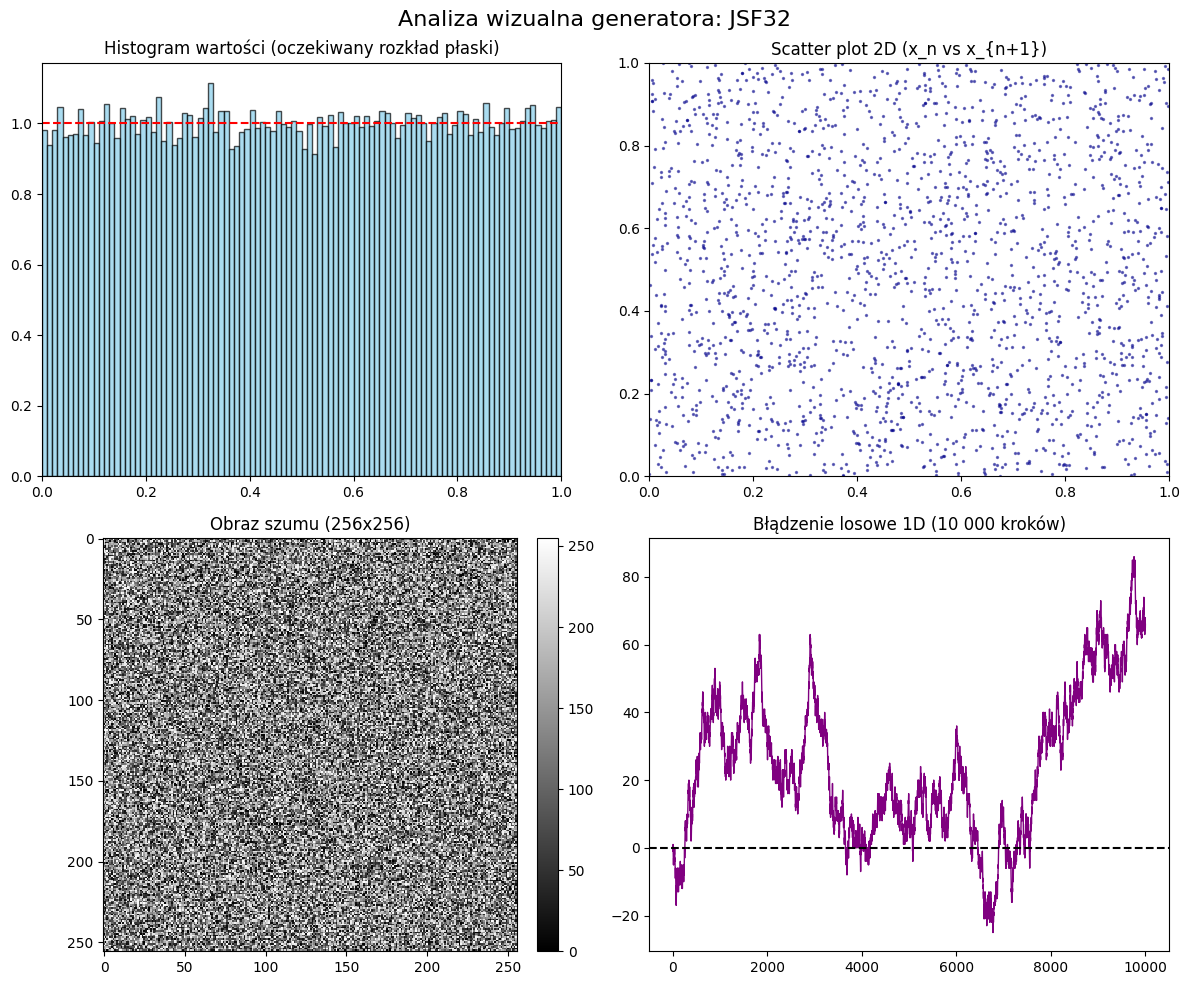

In [8]:
generator = JSF32(seed=12345)
results = validate_generator(generator, cfg)
print(json.dumps(results, indent=2))
run_visual_tests(generator)

## ChaCha20RNG

ChaCha20RNG to kryptograficznie bezpieczny generator liczb pseudolosowych. Zamiast używać klasycznych wzorów matematycznych lub prostego przesuwania bitów, algorytm ten opiera się na szyfrze strumieniowym ChaCha20. Generator ten działa poprzez "szyfrowanie" pustych danych za pomocą tajnego klucza (wynikającego z ziarna), co daje na wyjściu wysoce nieprzewidywalny ciąg liczb. Jest matematycznie bezpieczny. Nawet jeśli atakujący zdobędzie wygenerowane liczby, nie jest w stanie odtworzyć klucza (ziarna) ani przewidzieć kolejnych lub poprzednich wyników. Jest bardzo wydajny, między innymi dlatego, że pracuje blokowo i wykorzystuje buforowanie. 

Jest używany w systemach operacyjnyc np. Linux, generowania haseł i tokenów oraz w grach hazardowych.

Proces generowania:

1. Inicjalizacja: Podane przez użytkownika ziarno  jest przekształcane w 32-bajtowy klucz szyfrujący. Ustalana jest też wartość pomocnicza nonce (w implementacji są to same zera). Na ich podstawie inicjowany jest silnik szyfrujący ChaCha20.

2. Uzupełnianie bufora : Generator bierze 64-bajtowy blok składający się wyłącznie z samych zer (b"\x00" * 64) i przepuszcza go przez silnik generatora. W efekcie otrzymuje 64 bajty kryptograficznego "szumu" (tzw. strumień klucza). Wynik ten ląduje w wewnętrznym buforze.

3. Generowani  liczb: Kiedy użytkownik prosi o liczbę (np. 64-bitową przez _next_uint64), algorytm odcina wymagane 8 bajtów z bufora i konwertuje je na liczbę całkowitą.

Gdy bufor ulegnie wyczerpaniu, algorytm natychmiast wraca do punktu 2 – szyfruje kolejne paczki zer, uzupełniając bofor.

{
  "generator": "ChaCha20RNG",
  "summary_numbers": {
    "count": 5000.0,
    "mean": 9.231495361404115e+18,
    "variance": 2.825641481220535e+37,
    "std": 5.315676326884976e+18,
    "min": 2157382309773136.0,
    "max": 1.8439738994487894e+19
  },
  "summary_floats": {
    "count": 5000.0,
    "mean": 0.4999166110498798,
    "variance": 0.08414027514505037,
    "std": 0.2900694315936279,
    "min": 0.00045168627870761924,
    "max": 0.9997957463237338
  },
  "bit_balance": {
    "count": 10000,
    "zeros": 4941,
    "ones": 5059,
    "p_zero": 0.4941,
    "p_one": 0.5059
  },
  "serial_pairs": {
    "00": 2443,
    "01": 2498,
    "10": 2498,
    "11": 2560
  },
  "tests": {
    "monobit": {
      "statistic": 1.18,
      "p_value": 0.23800021491040146,
      "pass": true
    },
    "runs": {
      "statistic": 4997.0,
      "p_value": 0.9632445607062787,
      "pass": true
    },
    "chi_square_uint64_mod_256": {
      "statistic": 313.9456,
      "p_value": 0.0069190843392367

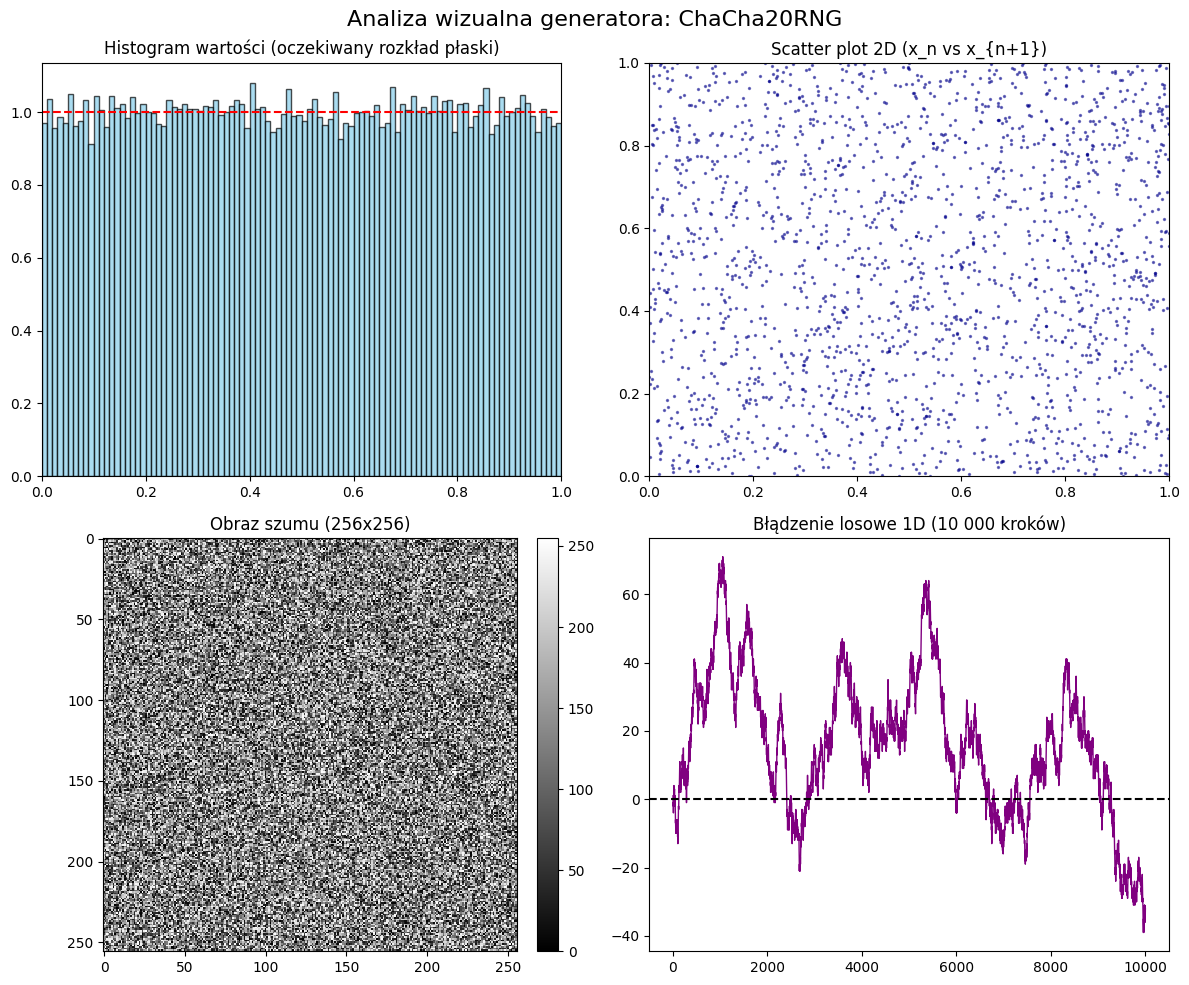

In [9]:
generator = ChaCha20RNG(seed=12345)
results = validate_generator(generator, cfg)
print(json.dumps(results, indent=2))
run_visual_tests(generator)